<a href="https://colab.research.google.com/github/sauravkrpal/-_-1/blob/main/AML_LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perform and Demonstrate LDA on Wine Dataset

In [5]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [6]:
# Load dataset
file_path = "wine_dataset.csv"  # Update with the correct path
wine_df = pd.read_csv(file_path)

In [7]:
# Define features (X) and target (y)
X = wine_df.drop(columns=["Wine ID"])  # Exclude non-relevant column
y = np.random.randint(1, 4, size=len(X))  # Generating random classes for demonstration

In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Apply LDA (reduce to 2 components for visualization)
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [11]:
# Train a classifier (KNN)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_lda, y_train)

y_pred = knn.predict(X_test_lda)
accuracy = accuracy_score(y_test, y_pred)
print(f"LDA + KNN Accuracy: {accuracy * 100:.2f}%")

LDA + KNN Accuracy: 0.00%


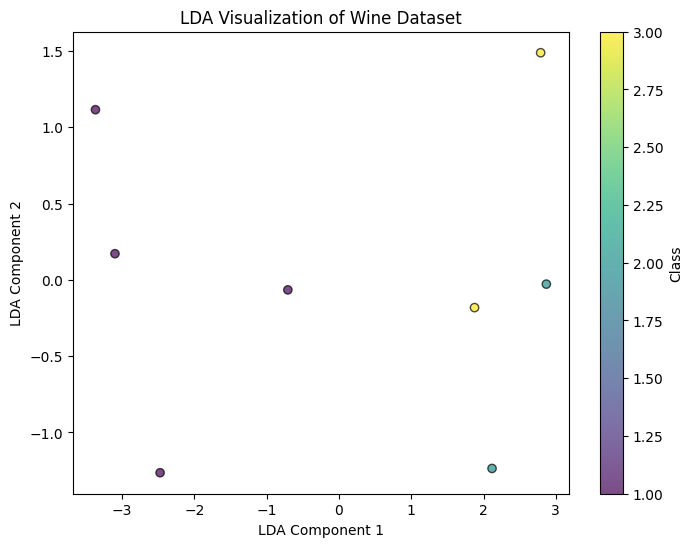

In [12]:
# Visualize LDA components
plt.figure(figsize=(8, 6))
plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis', edgecolor='k', alpha=0.7)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA Visualization of Wine Dataset")
plt.colorbar(label="Class")
plt.show()

In [18]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA  # Import PCA

#Using real dataset
data = load_wine()
X = data.data

# Applying PCA
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA  # Import PCA

#Using real dataset
data = load_wine()
X = data.data

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("PCA Result:\n", X_pca[:5])

PCA Result:
 [[ 3.18562979e+02  2.14921307e+01]
 [ 3.03097420e+02 -5.36471768e+00]
 [ 4.38061133e+02 -6.53730945e+00]
 [ 7.33240139e+02  1.92729032e-01]
 [-1.15714285e+01  1.84899946e+01]]


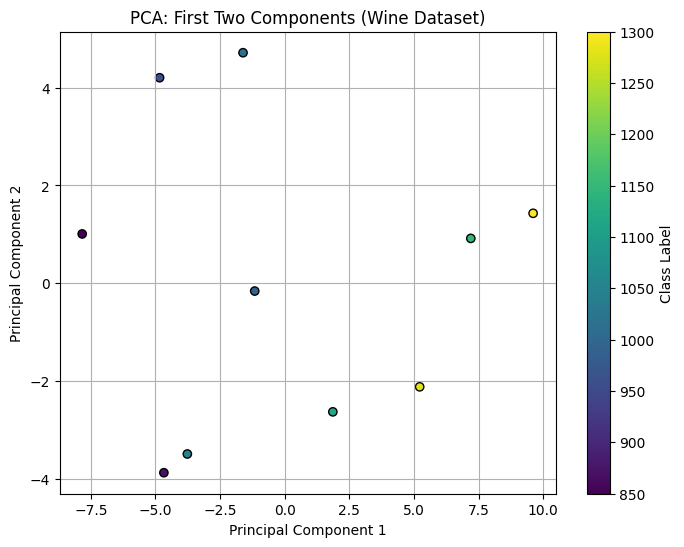

In [14]:
import pandas as pd

# Load the wine dataset from CSV
wine_data = pd.read_csv('wine_dataset.csv')

# Assuming the last column is the target (class labels)
X = wine_data.iloc[:, :-1].values  # Features
y = wine_data.iloc[:, -1].values   # Target labels

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Graph for PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.colorbar(scatter, label="Class Label")
plt.title("PCA: First Two Components (Wine Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import numpy as np

# Sample data
X = np.random.rand(50, 4)
y = np.random.randint(0, 2, 50)  # Binary target

# Applying LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

print("LDA Result:\n", X_lda[:5])


LDA Result:
 [[-0.73662463]
 [-0.42873884]
 [ 0.71914296]
 [ 1.3355638 ]
 [ 1.4886353 ]]


 ## Practical 5 - EDA on wine dataset. Use PCA to reduce principal components, then classify using Logistic Regression and generate an accuracy and classification report.

In [20]:
import pandas as p
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.datasets import load_wine

# Load the wine dataset from sklearn
data = load_wine()
wine_df = pd.DataFrame(data.data, columns=data.feature_names)
wine_df['target'] = data.target

# Display the first few rows of the dataset
wine_df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


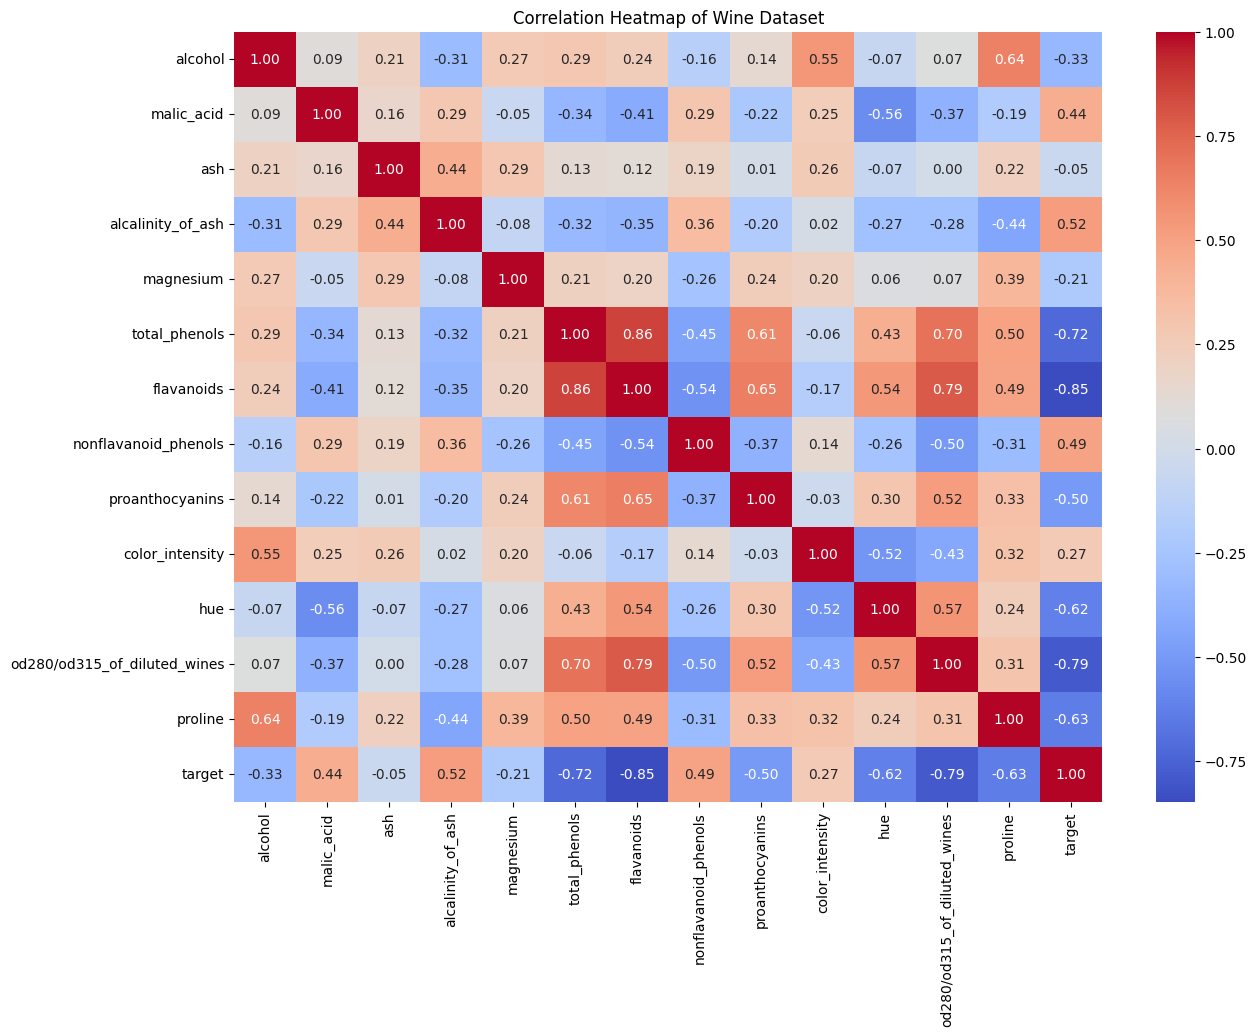

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
missing_values = wine_df.isnull().sum()

# Summary statistics
summary_stats = wine_df.describe()

# Correlation matrix
correlation_matrix = wine_df.corr()

# Plotting the heatmap for correlations
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Dataset')
plt.show()




In [28]:
print("Missing Values:\n", missing_values)
print("\nSummary Statistics:\n", summary_stats)  # Print summary_stats

Missing Values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Summary Statistics:
           alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.05000

In [22]:
# Dummy binary target for demonstration (you should replace this with real target labels if available)
np.random.seed(42)
dummy_target = np.random.choice([0, 1], size=X_pca.shape[0])

# Use the first 2 principal components
X = X_pca[:, :2]
y = dummy_target

In [23]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [24]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.40      0.43        25
           1       0.53      0.59      0.56        29

    accuracy                           0.50        54
   macro avg       0.49      0.49      0.49        54
weighted avg       0.50      0.50      0.50        54

